In [2]:
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Masquer la fenêtre principale Tkinter
root = Tk()
root.withdraw()

# Forcer la fenêtre à être au premier plan
root.attributes('-topmost', True)
root.update()

# Ouvrir la fenêtre de sélection
fichier = filedialog.askopenfilename(
    title="Choisissez le fichier à analyser",
    filetypes=[("Fichiers CSV", "*.csv"), ("Fichiers Excel", "*.xlsx *.xls"), ("Tous les fichiers", "*.*")]
)

In [3]:
# Lecture du fichier sélectionné avec pandas
df = pd.read_csv(fichier)

C:\Users\asmaj\AppData\Local\Temp\ipykernel_21136\541779158.py:2: DtypeWarning: Columns (77) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fichier)


### CONDITIONS MÉTÉO & ENVIRONNEMENT

### Sévérité des accidents selon la météo (BOXPLOT)

Question: Certaines conditions météo rendent-elles les accidents plus graves ?

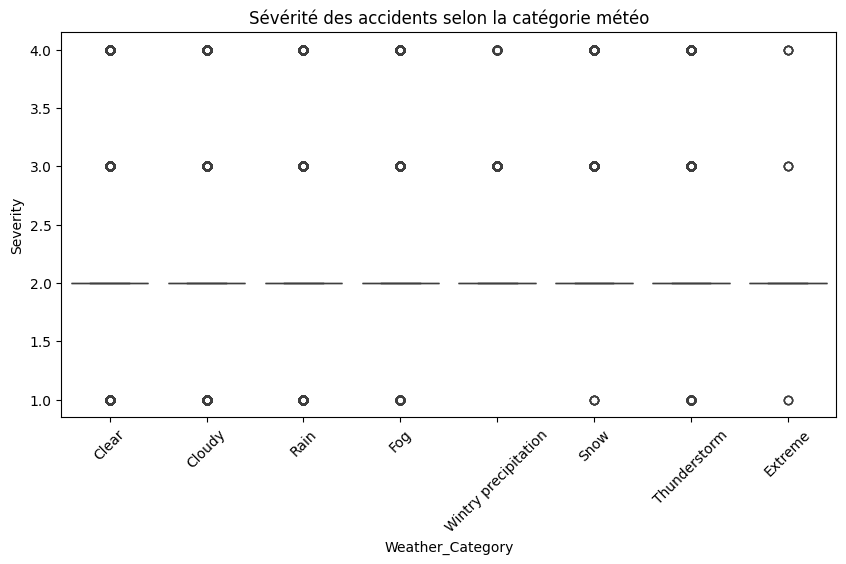

In [2]:
df_sample_not_unknown = df[df['Weather_Category'] != 'Unknown']
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df_sample_not_unknown,
    x='Weather_Category',
    y='Severity'
)
plt.xticks(rotation=45)
plt.title("Sévérité des accidents selon la catégorie météo")
plt.show()

<style>
T1 {
    display: inline-block;
    background: #fde2d2;
    color: #c95305;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 19px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Visualisation infrastructurelles 🚧</T1>

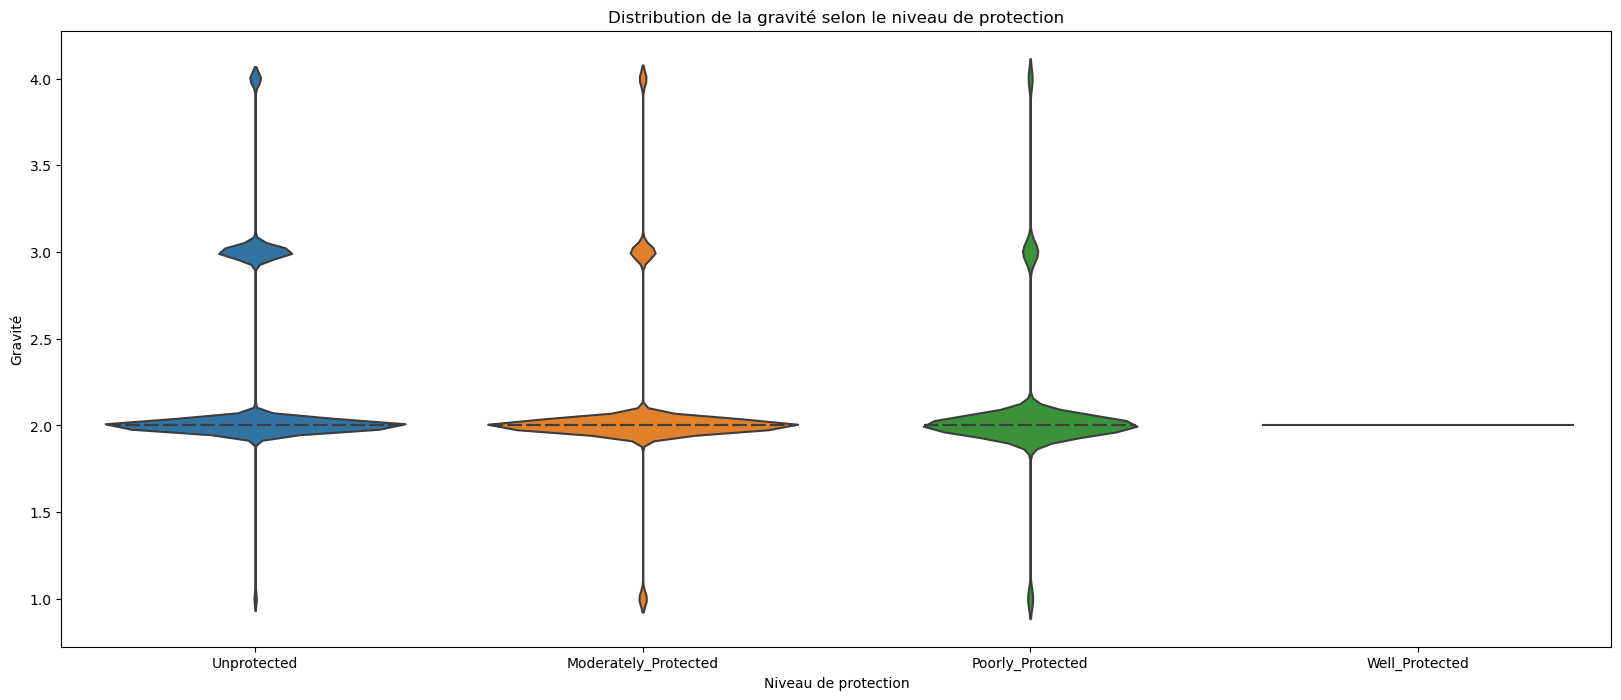

In [ ]:
# VIOLIN PLOT — Gravité selon le niveau de protection
# Le niveau de protection influence-t-il la distribution de la gravité ?

plt.figure(figsize=(20,8))
sns.violinplot(
    data=df,
    x='Protection_Level',
    y='Severity',
    inner='quartile'
)
plt.title("Distribution de la gravité selon le niveau de protection")
plt.xlabel("Niveau de protection")
plt.ylabel("Gravité")
plt.show()

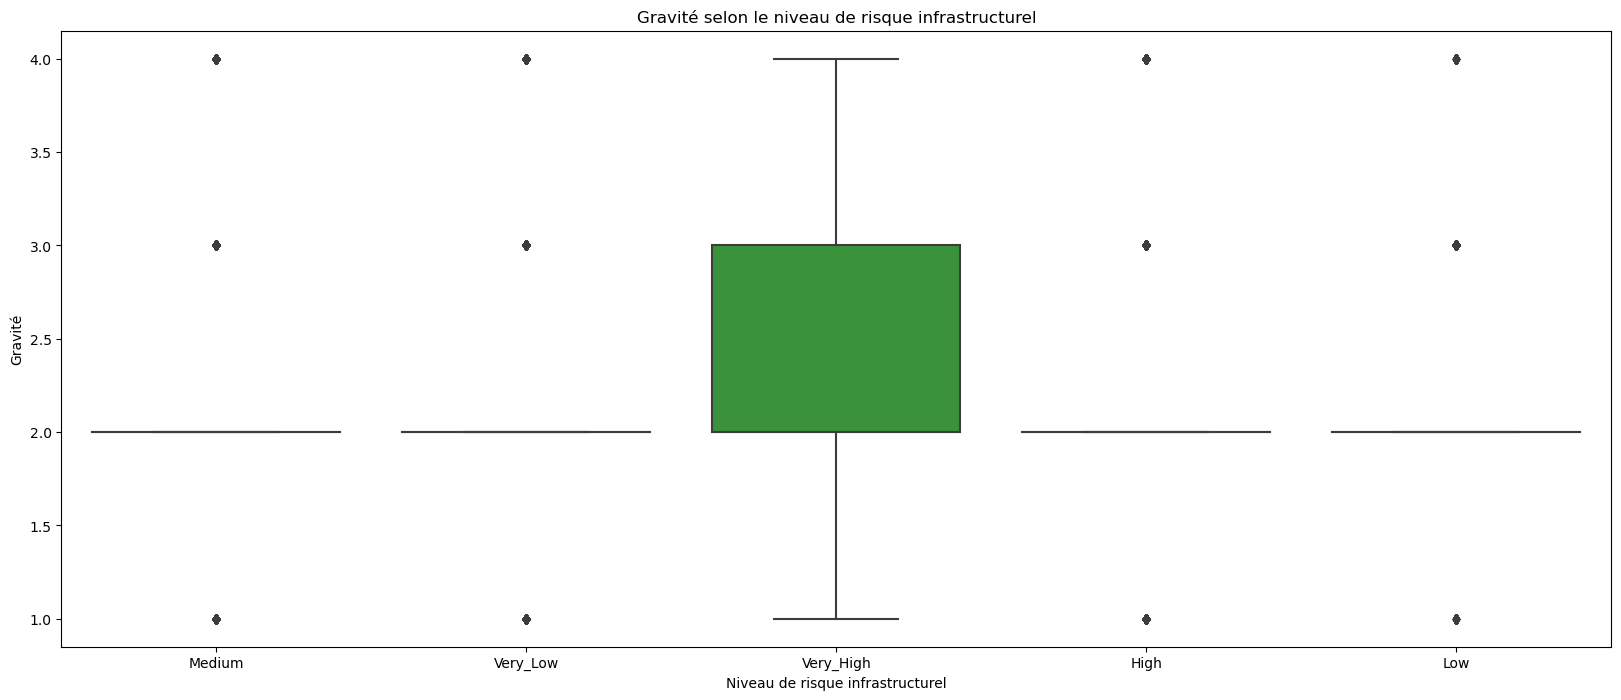

In [33]:
# BOXPLOT — Infrastructure_Risk_Category vs Severity
# Le score de risque infrastructurel est-il cohérent avec la gravité observée ?

plt.figure(figsize=(20,8))
sns.boxplot(
    data=df,
    x='Infrastructure_Risk_Category',
    y='Severity'
)
plt.title("Gravité selon le niveau de risque infrastructurel")
plt.xlabel("Niveau de risque infrastructurel")
plt.ylabel("Gravité")
plt.show()

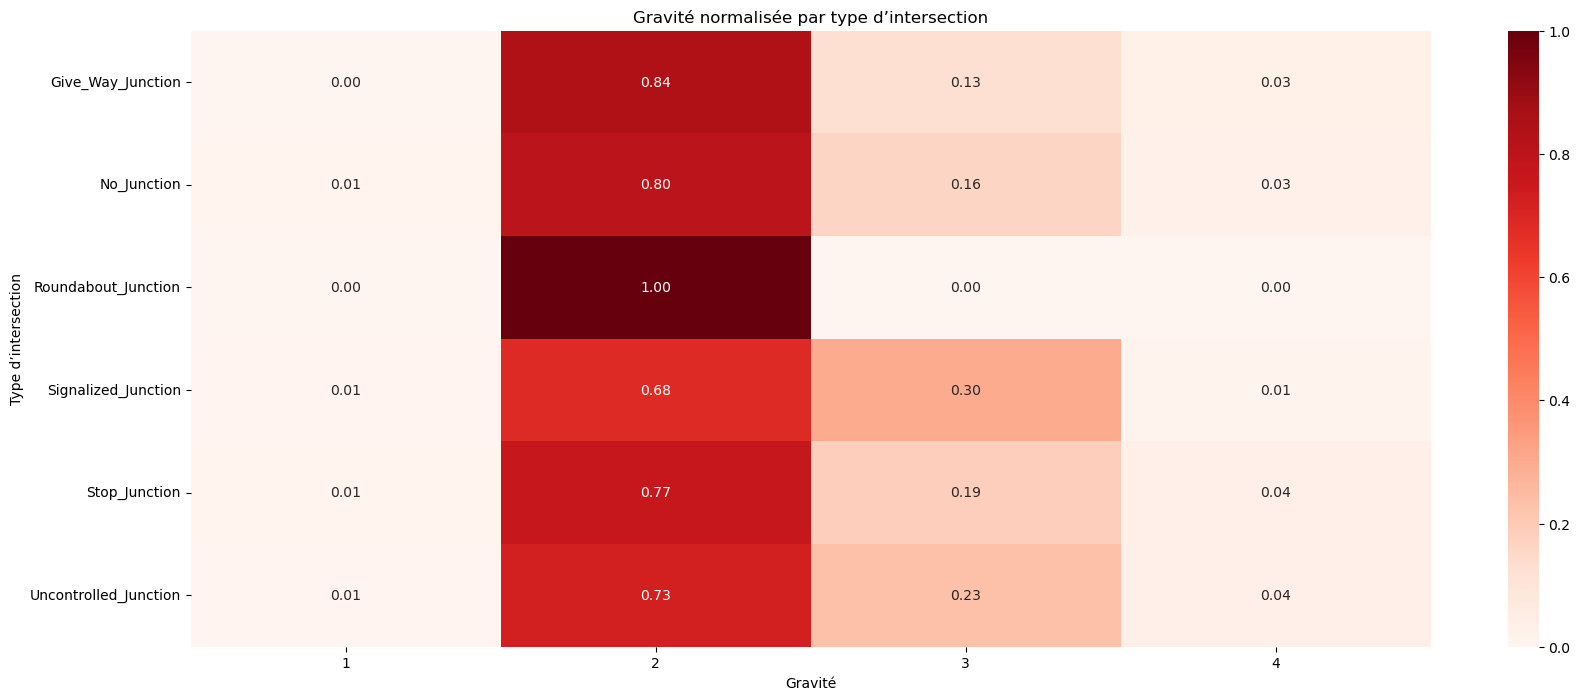

In [32]:
# HEATMAP NORMALISÉE — Junction_Type × Severity
# Quels types d’intersections concentrent les accidents graves ?

junction_sev = (
    df
    .groupby(['Junction_Type', 'Severity'])
    .size()
    .unstack(fill_value=0)
)

junction_sev_norm = junction_sev.div(junction_sev.sum(axis=1), axis=0)

plt.figure(figsize=(20,8))
sns.heatmap(
    junction_sev_norm,
    annot=True,
    fmt=".2f",
    cmap="Reds"
)
plt.title("Gravité normalisée par type d’intersection")
plt.xlabel("Gravité")
plt.ylabel("Type d’intersection")
plt.show()


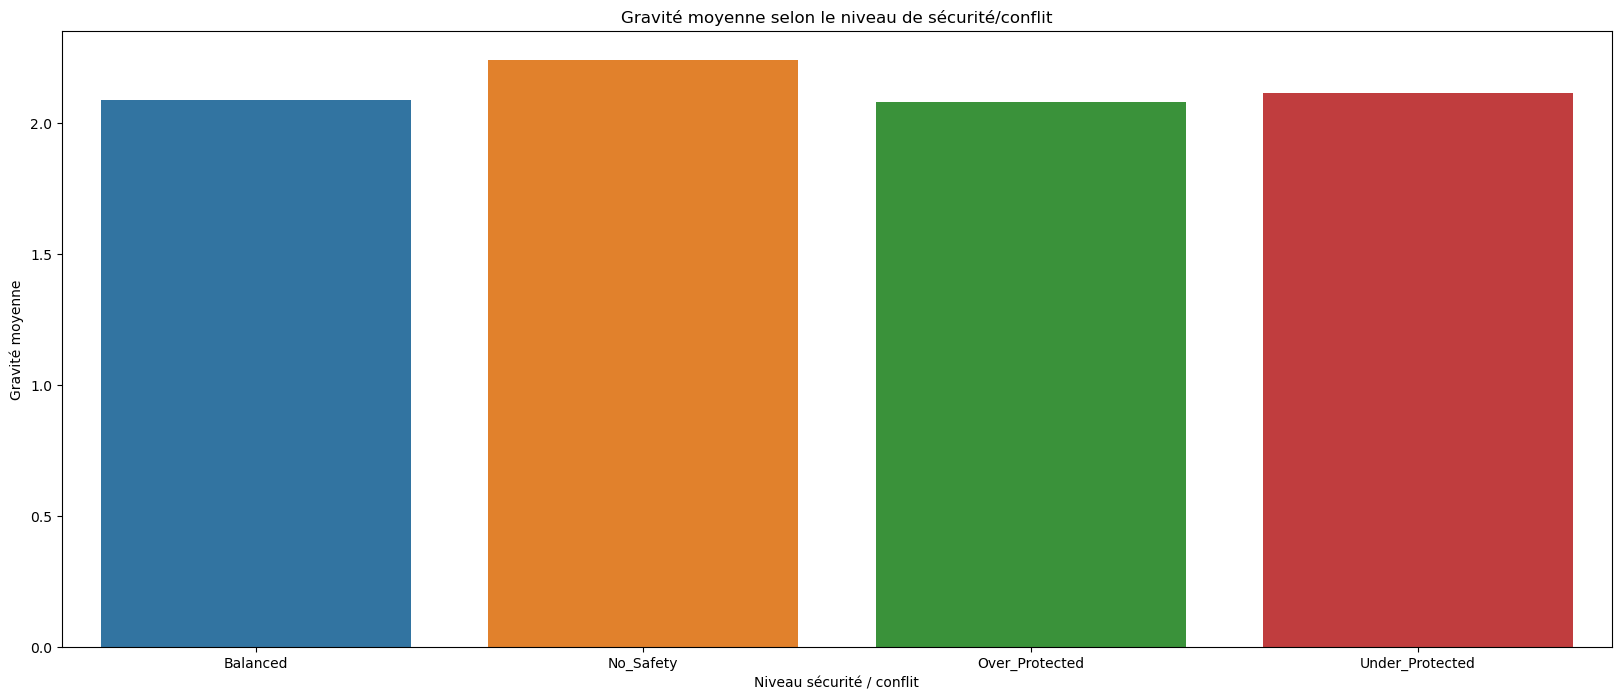

In [31]:
# BAR PLOT COMPARATIF — Sécurité vs Conflit
# Est-ce que la sécurité compense réellement les points de conflit ?

grouped = (
    df
    .groupby('Safety_Level')['Severity']
    .mean()
    .reset_index()
)

plt.figure(figsize=(20,8))
sns.barplot(
    data=grouped,
    x='Safety_Level',
    y='Severity'
)
plt.title("Gravité moyenne selon le niveau de sécurité/conflit")
plt.xlabel("Niveau sécurité / conflit")
plt.ylabel("Gravité moyenne")
plt.show()


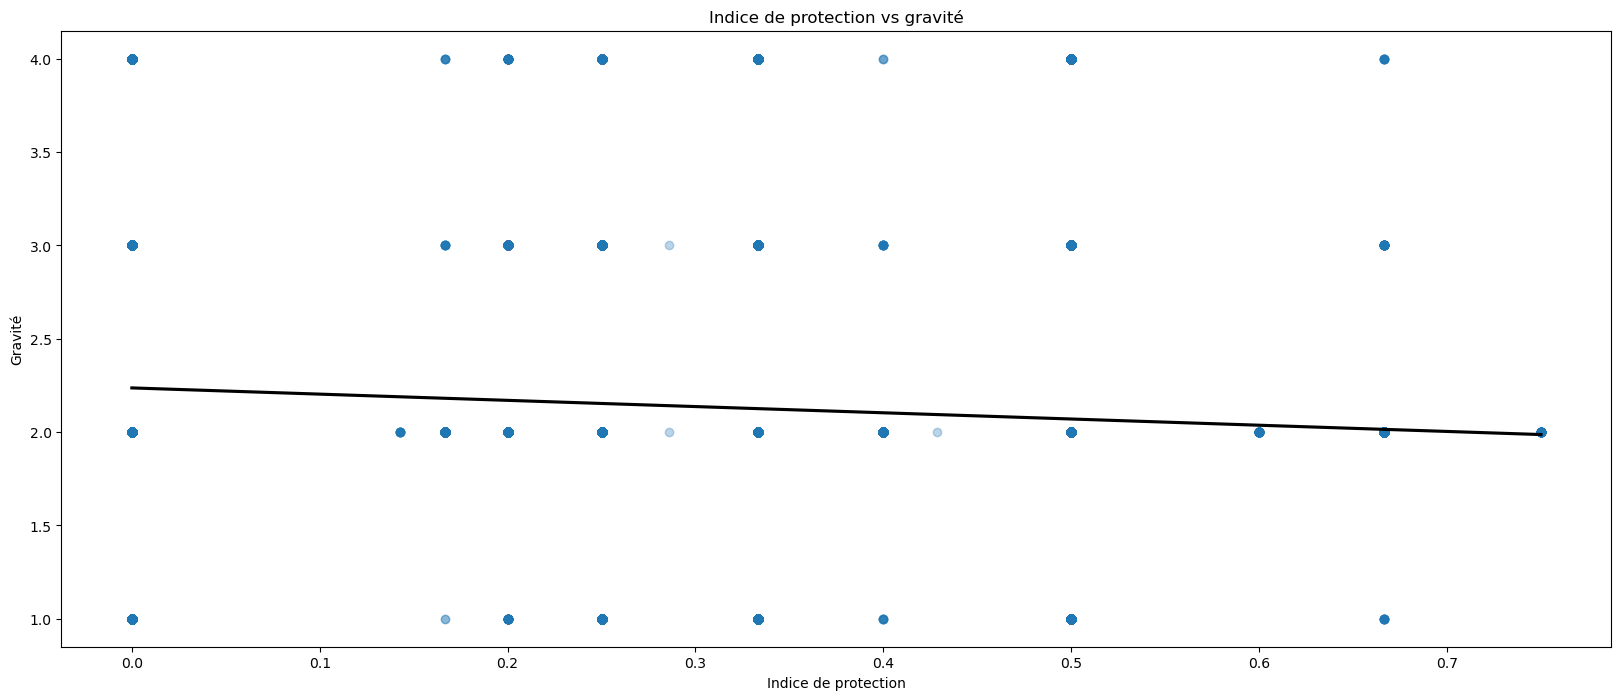

In [30]:
# SCATTER + TENDANCE — Protection_Index vs Severity
# Plus la proportion de dispositifs de sécurité est élevée, plus la gravité baisse ?

plt.figure(figsize=(20,8))
sns.regplot(
    data=df,
    x='Protection_Index',
    y='Severity',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'black'}
)
plt.title("Indice de protection vs gravité")
plt.xlabel("Indice de protection")
plt.ylabel("Gravité")
plt.show()


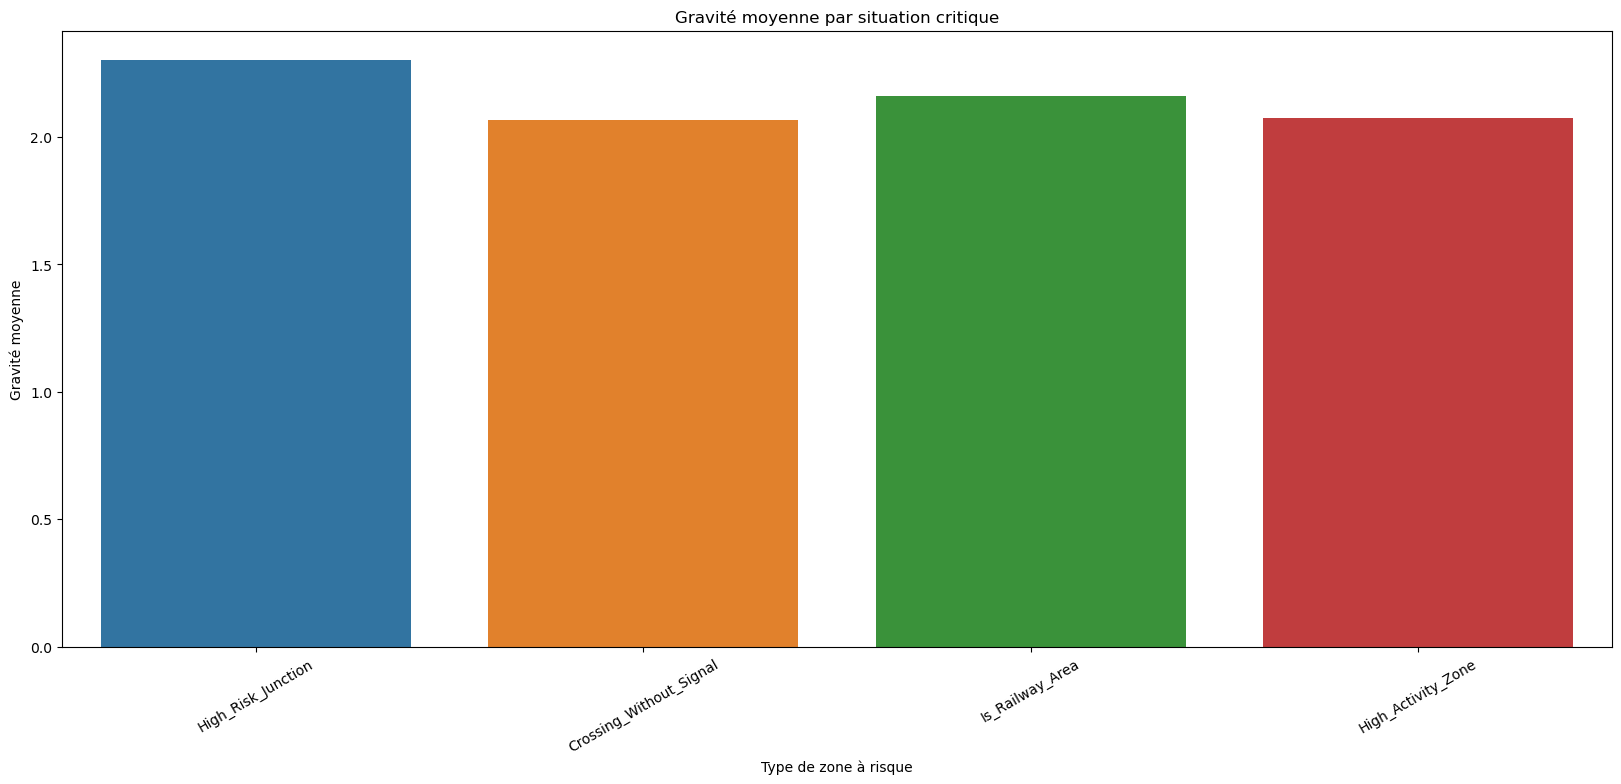

In [29]:
# BAR PLOT — Zones critiques ciblées
# Quelles situations spécifiques sont les plus dangereuses ?

risk_features = [
    'High_Risk_Junction',
    'Crossing_Without_Signal',
    'Is_Railway_Area',
    'High_Activity_Zone'
]

risk_sev = {
    col: df.loc[df[col]==1, 'Severity'].mean()
    for col in risk_features
}

risk_df = pd.DataFrame.from_dict(
    risk_sev, orient='index', columns=['Mean_Severity']
).reset_index()

plt.figure(figsize=(20,8))
sns.barplot(
    data=risk_df,
    x='index',
    y='Mean_Severity'
)
plt.title("Gravité moyenne par situation critique")
plt.xlabel("Type de zone à risque")
plt.ylabel("Gravité moyenne")
plt.xticks(rotation=30)
plt.show()


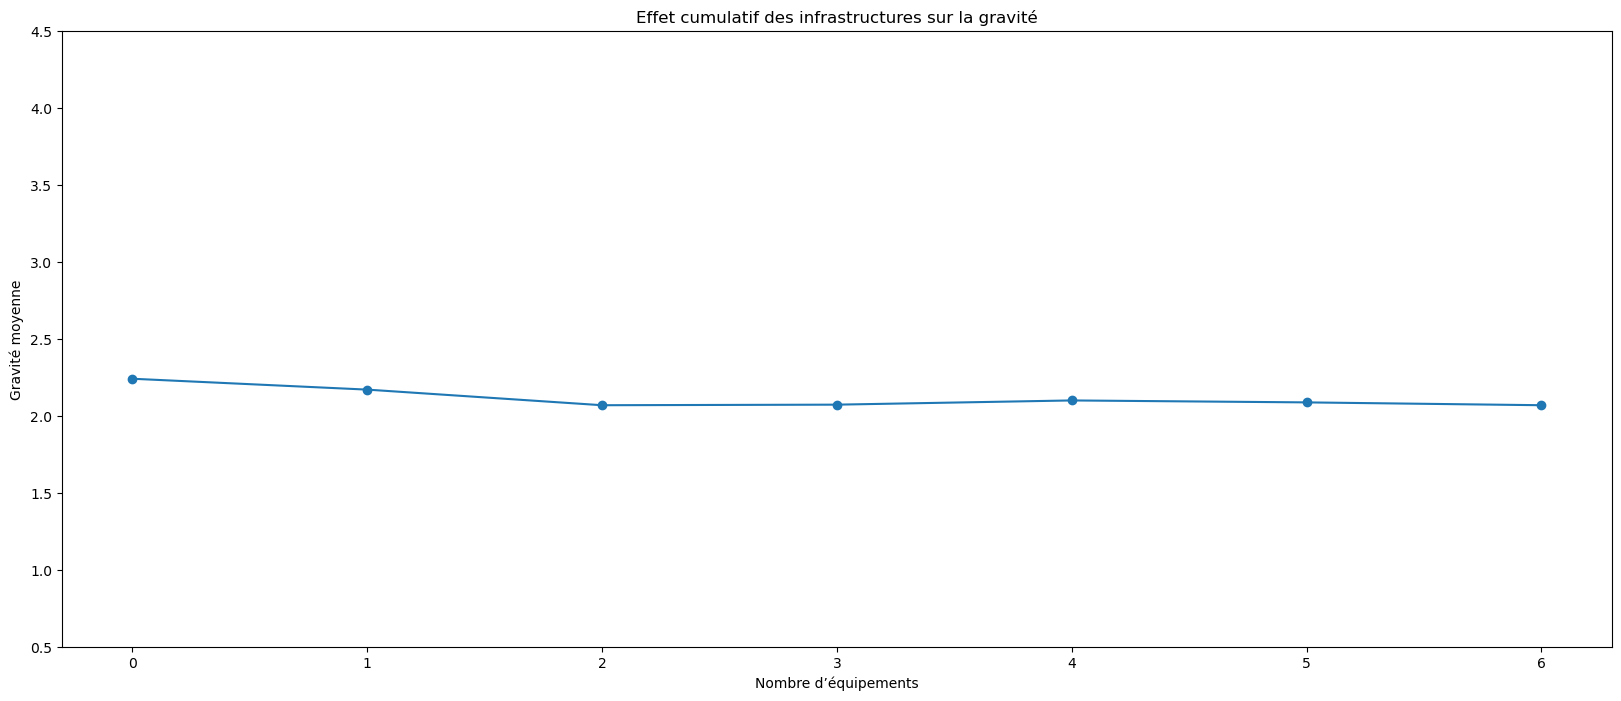

In [28]:
# Line plot – Gravité moyenne selon Infrastructure_Count 
# Visualiser l’effet cumulatif des équipements

infra_sev = df.groupby('Infrastructure_Count')['Severity'].mean()

plt.figure(figsize=(20,8))
plt.plot(infra_sev.index, infra_sev.values, marker='o')
plt.xlabel("Nombre d’équipements")
plt.ylabel("Gravité moyenne")
plt.title("Effet cumulatif des infrastructures sur la gravité")
plt.ylim(0.5,4.5)
plt.show()
